In [368]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler,MinMaxScaler



In [369]:
data=pd.read_csv('/content/train_loan_preprocess.csv')

In [370]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [371]:
data.shape

(614, 13)

In [372]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [373]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [374]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [375]:
data.duplicated().sum()

0

In [376]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [377]:
data['Married'].unique()

array(['No', 'Yes', nan], dtype=object)

array([[<Axes: title={'center': 'ApplicantIncome'}>,
        <Axes: title={'center': 'CoapplicantIncome'}>],
       [<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'Loan_Amount_Term'}>],
       [<Axes: title={'center': 'Credit_History'}>, <Axes: >]],
      dtype=object)

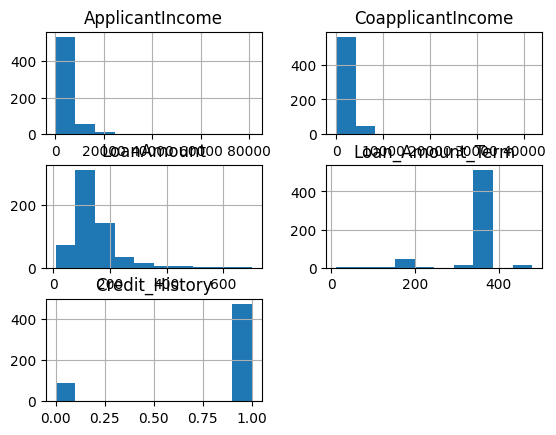

In [378]:

data.hist()

In [379]:
categorical_columns = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for column in categorical_columns:
    mode_value = data[column].mode()[0]
    data[column].fillna(mode_value, inplace=True)

In [380]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [381]:
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [382]:
numerical_columns = ['LoanAmount', 'Loan_Amount_Term','Credit_History']  # Replace with your numerical columns

for column in numerical_columns:
    mean_value = data[column].mean()
    data[column].fillna(mean_value, inplace=True)

In [383]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'ApplicantIncome'),
  Text(2, 0, 'CoapplicantIncome'),
  Text(3, 0, 'LoanAmount'),
  Text(4, 0, 'Loan_Amount_Term'),
  Text(5, 0, 'Credit_History')])

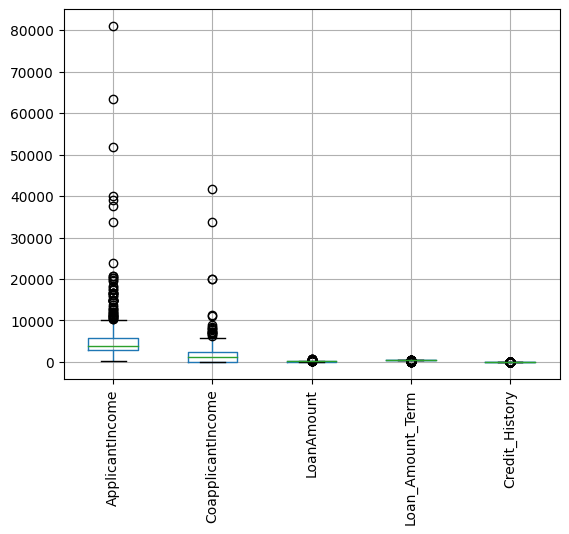

In [384]:
import matplotlib.pyplot as plt
data.boxplot()
plt.xticks(rotation=90)

In [385]:
q1=np.percentile(data['ApplicantIncome'],25,interpolation='midpoint')
q2=np.percentile(data['ApplicantIncome'],50,interpolation='midpoint')
q3=np.percentile(data['ApplicantIncome'],75,interpolation='midpoint')
print(q1,q2,q3)
iqr=q3-q1
iqr

2879.0 3812.5 5790.0


2911.0

In [386]:
min_val=q1-1.5*iqr
max_val=q3+1.5*iqr
print(min_val,max_val)

-1487.5 10156.5


In [387]:
outliers=[]
for x in data['ApplicantIncome']:
  if((x>max_val)or(x<min_val)):
    outliers.append(x)
data['ApplicantIncome']=data['ApplicantIncome'].clip(min_val,max_val)

(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'ApplicantIncome'),
  Text(2, 0, 'CoapplicantIncome'),
  Text(3, 0, 'LoanAmount'),
  Text(4, 0, 'Loan_Amount_Term'),
  Text(5, 0, 'Credit_History')])

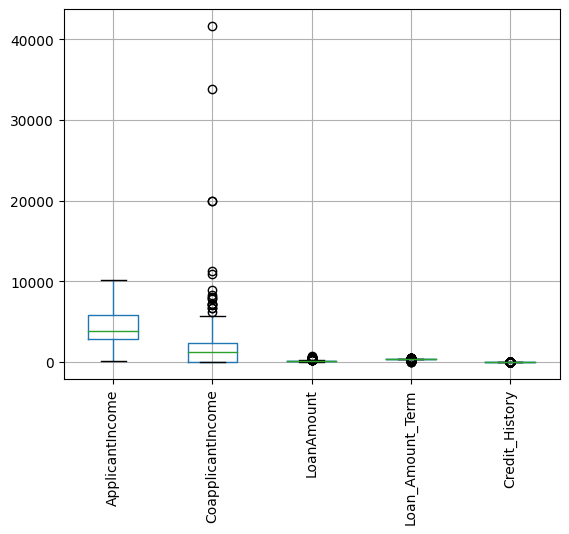

In [388]:
data.boxplot()
plt.xticks(rotation=90)

In [389]:
q1=np.percentile(data['CoapplicantIncome'],25,interpolation='midpoint')
q2=np.percentile(data['CoapplicantIncome'],50,interpolation='midpoint')
q3=np.percentile(data['CoapplicantIncome'],75,interpolation='midpoint')
print(q1,q2,q3)
iqr=q3-q1
iqr

0.0 1188.5 2292.5


2292.5

In [390]:
min_val=q1-1.5*iqr
max_val=q3+1.5*iqr
print(min_val,max_val)

-3438.75 5731.25


In [391]:
outliers=[]
for x in data['CoapplicantIncome']:
  if((x>max_val)or(x<min_val)):
    outliers.append(x)
data['CoapplicantIncome']=data['CoapplicantIncome'].clip(min_val,max_val)

(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'ApplicantIncome'),
  Text(2, 0, 'CoapplicantIncome'),
  Text(3, 0, 'LoanAmount'),
  Text(4, 0, 'Loan_Amount_Term'),
  Text(5, 0, 'Credit_History')])

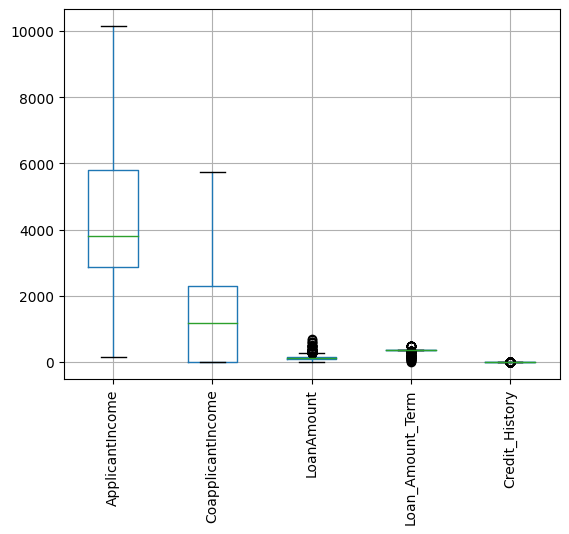

In [392]:
data.boxplot()
plt.xticks(rotation=90)

In [393]:
q1=np.percentile(data['LoanAmount'],25,interpolation='midpoint')
q2=np.percentile(data['LoanAmount'],50,interpolation='midpoint')
q3=np.percentile(data['LoanAmount'],75,interpolation='midpoint')
print(q1,q2,q3)
iqr=q3-q1
iqr

100.5 129.0 164.5


64.0

In [394]:
min_val=q1-1.5*iqr
max_val=q3+1.5*iqr
print(min_val,max_val)

4.5 260.5


In [395]:
outliers=[]
for x in data['LoanAmount']:
  if((x>max_val)or(x<min_val)):
    outliers.append(x)
data['LoanAmount']=data['LoanAmount'].clip(min_val,max_val)

(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'ApplicantIncome'),
  Text(2, 0, 'CoapplicantIncome'),
  Text(3, 0, 'LoanAmount'),
  Text(4, 0, 'Loan_Amount_Term'),
  Text(5, 0, 'Credit_History')])

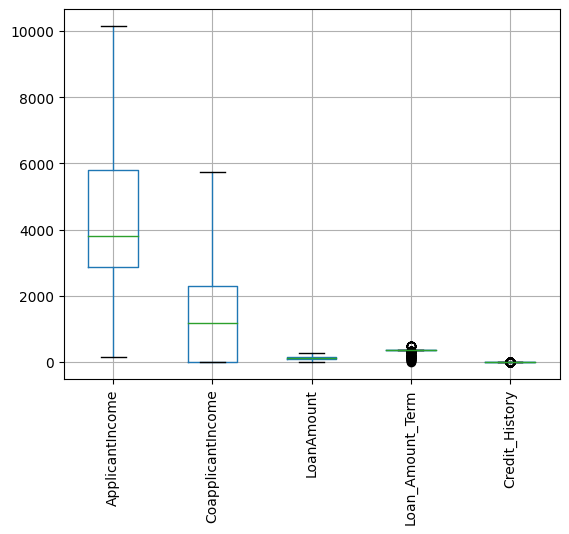

In [396]:
data.boxplot()
plt.xticks(rotation=90)

In [397]:
q1=np.percentile(data['Loan_Amount_Term'],25,interpolation='midpoint')
q2=np.percentile(data['Loan_Amount_Term'],50,interpolation='midpoint')
q3=np.percentile(data['Loan_Amount_Term'],75,interpolation='midpoint')
print(q1,q2,q3)
iqr=q3-q1
iqr

360.0 360.0 360.0


0.0

In [398]:
min_val=q1-1.5*iqr
max_val=q3+1.5*iqr
print(min_val,max_val)

360.0 360.0


In [399]:
outliers=[]
for x in data['Loan_Amount_Term']:
  if((x>max_val)or(x<min_val)):
    outliers.append(x)
print(outliers)
data['Loan_Amount_Term']=data['Loan_Amount_Term'].clip(min_val,max_val)

[120.0, 240.0, 342.0, 342.0, 342.0, 342.0, 180.0, 180.0, 60.0, 300.0, 342.0, 480.0, 300.0, 240.0, 180.0, 120.0, 180.0, 180.0, 480.0, 342.0, 180.0, 180.0, 480.0, 120.0, 180.0, 180.0, 180.0, 180.0, 342.0, 480.0, 300.0, 180.0, 480.0, 180.0, 300.0, 180.0, 342.0, 180.0, 342.0, 480.0, 180.0, 342.0, 180.0, 60.0, 180.0, 180.0, 480.0, 180.0, 36.0, 180.0, 300.0, 480.0, 480.0, 84.0, 180.0, 180.0, 180.0, 342.0, 180.0, 480.0, 300.0, 480.0, 342.0, 300.0, 180.0, 180.0, 480.0, 180.0, 180.0, 180.0, 300.0, 300.0, 342.0, 342.0, 180.0, 240.0, 300.0, 300.0, 180.0, 180.0, 180.0, 180.0, 300.0, 84.0, 12.0, 480.0, 300.0, 180.0, 480.0, 180.0, 180.0, 36.0, 180.0, 480.0, 84.0, 84.0, 180.0, 240.0, 180.0, 180.0, 180.0, 180.0]


(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'ApplicantIncome'),
  Text(2, 0, 'CoapplicantIncome'),
  Text(3, 0, 'LoanAmount'),
  Text(4, 0, 'Loan_Amount_Term'),
  Text(5, 0, 'Credit_History')])

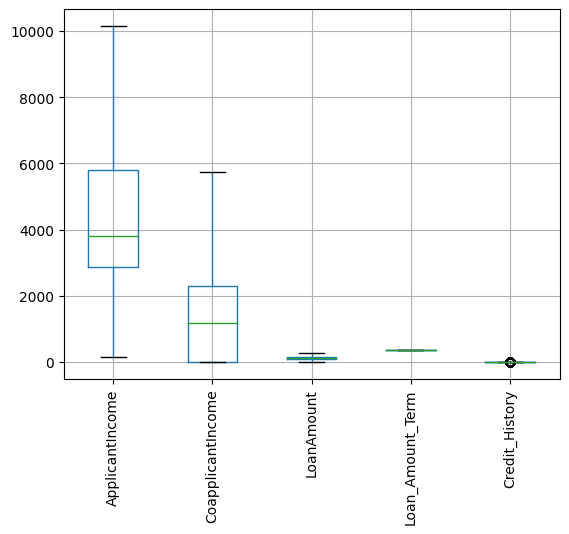

In [400]:
data.boxplot()
plt.xticks(rotation=90)

In [401]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y


In [402]:
q1=np.percentile(data['Credit_History'],25,interpolation='midpoint')
q2=np.percentile(data['Credit_History'],50,interpolation='midpoint')
q3=np.percentile(data['Credit_History'],75,interpolation='midpoint')
print(q1,q2,q3)
iqr=q3-q1
iqr

1.0 1.0 1.0


0.0

In [403]:
min_val=q1-1.5*iqr
max_val=q3+1.5*iqr
print(min_val,max_val)

1.0 1.0


In [404]:
outliers=[]
for x in data['Credit_History']:
  if((x>max_val)or(x<min_val)):
    outliers.append(x)
print(outliers)
data['Credit_History']=data['Credit_History'].clip(min_val,max_val)

[0.0, 0.8421985815602837, 0.0, 0.0, 0.0, 0.0, 0.8421985815602837, 0.8421985815602837, 0.0, 0.8421985815602837, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8421985815602837, 0.8421985815602837, 0.8421985815602837, 0.8421985815602837, 0.0, 0.0, 0.8421985815602837, 0.0, 0.8421985815602837, 0.0, 0.8421985815602837, 0.8421985815602837, 0.0, 0.0, 0.0, 0.8421985815602837, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8421985815602837, 0.0, 0.8421985815602837, 0.8421985815602837, 0.0, 0.0, 0.0, 0.8421985815602837, 0.0, 0.8421985815602837, 0.8421985815602837, 0.0, 0.0, 0.0, 0.8421985815602837, 0.8421985815602837, 0.0, 0.8421985815602837, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8421985815602837, 0.8421985815602837, 0.8421985815602837, 0.8421985815602837, 0.8421985815602837, 0.0, 0.0, 0.0, 0.0, 0.8421985815602837, 0.0, 0.0, 0.8421985815602837, 0.0, 0.0, 0.8421985815602837, 0.0, 0.8421985815602837, 0.8421985815602837, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8421985815602837, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8421985815602837, 0.0, 0.8421985

(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'ApplicantIncome'),
  Text(2, 0, 'CoapplicantIncome'),
  Text(3, 0, 'LoanAmount'),
  Text(4, 0, 'Loan_Amount_Term'),
  Text(5, 0, 'Credit_History')])

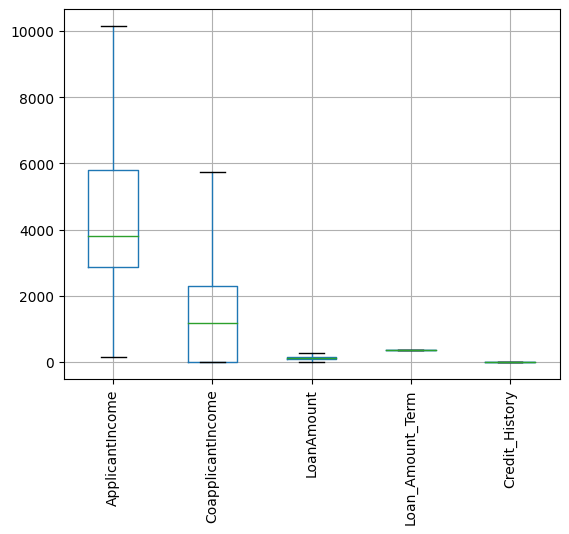

In [405]:
data.boxplot()
plt.xticks(rotation=90)

In [406]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.0,614.0
mean,4615.910423,1419.354104,137.958579,360.0,1.0
std,2477.158964,1623.678913,55.626244,0.0,0.0
min,150.000000,0.000000,9.000000,360.0,1.0
25%,2877.500000,0.000000,100.250000,360.0,1.0
50%,3812.500000,1188.500000,129.000000,360.0,1.0
75%,5795.000000,2297.250000,164.750000,360.0,1.0
max,10156.500000,5731.250000,260.500000,360.0,1.0


Encoding & scaling

In [407]:
data
data1=data.copy()


In [408]:
label_encoder = LabelEncoder()
data['LoanID_encoded'] = label_encoder.fit_transform(data['Loan_ID'])
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanID_encoded
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,2
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,3
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,609
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,610
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,611
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,612


In [409]:
data['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [410]:
one_hot_encoder = OneHotEncoder(sparse=False)
one_hot_encoded = one_hot_encoder.fit_transform(data[['Property_Area']])
one_hot_encoded

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [411]:
one_hot_data = pd.DataFrame(one_hot_encoded, columns=one_hot_encoder.get_feature_names_out(['Property_Area']))
data = pd.concat([data, one_hot_data], axis=1)
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanID_encoded,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,0,0.0,0.0,1.0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,1,1.0,0.0,0.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,2,0.0,0.0,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,3,0.0,0.0,1.0
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,4,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,609,1.0,0.0,0.0
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,610,1.0,0.0,0.0
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,611,0.0,0.0,1.0
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,612,0.0,0.0,1.0


In [412]:
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y


In [413]:
data1_encoded = pd.get_dummies(data1, columns=['Gender'],dtype=int, prefix='p')
data1_encoded

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,p_Female,p_Male
0,LP001002,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,0,1
1,LP001003,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,0,1
2,LP001005,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,0,1
3,LP001006,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,0,1
4,LP001008,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,1,0
610,LP002979,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,0,1
611,LP002983,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,0,1
612,LP002984,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,0,1


In [414]:
ord_encoder = OrdinalEncoder()
data1['Property_Area_encoded'] = ord_encoder.fit_transform(data1[['Property_Area']])
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Property_Area_encoded
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,2.0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,0.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,2.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,2.0
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,0.0
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,0.0
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,2.0
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,2.0


In [415]:
ord_encoder = OrdinalEncoder()
data1['Married_encoded'] = ord_encoder.fit_transform(data1[['Married']])
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Property_Area_encoded,Married_encoded
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,2.0,0.0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,0.0,1.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,2.0,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,2.0,1.0
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,0.0,0.0
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,0.0,1.0
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,2.0,1.0
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,2.0,1.0


In [416]:
ord_encoder = OrdinalEncoder()
data1['LoanStatus_encoded'] = ord_encoder.fit_transform(data1[['Loan_Status']])
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Property_Area_encoded,Married_encoded,LoanStatus_encoded
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,2.0,0.0,1.0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,0.0,1.0,0.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,0.0,0.0,1.0
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,0.0,1.0,1.0
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0


In [417]:
std_scaler = StandardScaler()
data1['LoanAmt_scaled'] = std_scaler.fit_transform(data1[['LoanAmount']])
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Property_Area_encoded,Married_encoded,LoanStatus_encoded,LoanAmt_scaled
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,2.0,0.0,1.0,0.152095
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,0.0,1.0,0.0,-0.179173
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,-1.294663
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,-0.323107
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,2.0,0.0,1.0,0.054721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,0.0,0.0,1.0,-1.204704
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,0.0,1.0,1.0,-1.762450
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,2.069800
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,0.882343


In [418]:
minmax_scaler = MinMaxScaler()
data1['LoanAmt_minscaled'] = minmax_scaler.fit_transform(data1[['LoanAmount']])
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Property_Area_encoded,Married_encoded,LoanStatus_encoded,LoanAmt_scaled,LoanAmt_minscaled
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y,2.0,0.0,1.0,0.152095,0.546370
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,0.0,1.0,0.0,-0.179173,0.473161
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,-1.294663,0.226640
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,-0.323107,0.441352
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,2.0,0.0,1.0,0.054721,0.524851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.000000,360.0,1.0,Rural,Y,0.0,0.0,1.0,-1.204704,0.246521
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.000000,360.0,1.0,Rural,Y,0.0,1.0,1.0,-1.762450,0.123260
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,2.069800,0.970179
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.000000,360.0,1.0,Urban,Y,2.0,1.0,1.0,0.882343,0.707753


In [419]:
minmax_scaler = MinMaxScaler()
scale_columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanStatus_encoded']
data2 = data1.copy()
data2 = data2.drop(columns=['Loan_ID','Gender'	,'Married',	'Dependents'	,'Education',	'Self_Employed'	,	'Loan_Amount_Term',	'Credit_History',	'Property_Area',	'Property_Area_encoded','LoanAmt_scaled',	'LoanAmt_minscaled'])
for col in scale_columns:
    data2[col] = minmax_scaler.fit_transform(data2[[col]])
data2.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Status,Married_encoded,LoanStatus_encoded
0,0.569530,0.000000,146.412162,Y,0.0,1.0
1,0.443012,0.263119,128.000000,N,1.0,0.0
2,0.284815,0.000000,66.000000,Y,1.0,1.0
3,0.243142,0.411429,120.000000,Y,1.0,1.0
4,0.584620,0.000000,141.000000,Y,0.0,1.0


In [420]:
corr_columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanStatus_encoded']
corr_matrix = data2[corr_columns].corr()
corr_matrix

,ApplicantIncome,CoapplicantIncome,LoanStatus_encoded
ApplicantIncome,1.000000,-0.229124,-0.000414
CoapplicantIncome,-0.229124,1.000000,0.012051
LoanStatus_encoded,-0.000414,0.012051,1.000000


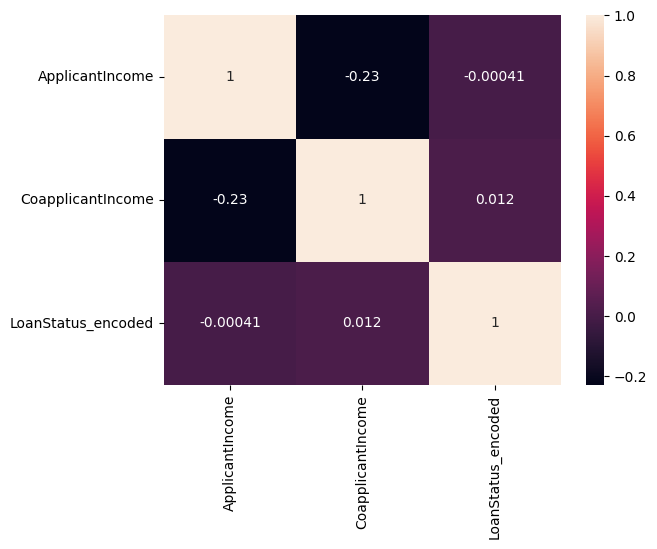

In [421]:

sns.heatmap(corr_matrix, annot=True)
plt.show()